开始分析音频文件...


100%|██████████| 832/832 [00:04<00:00, 167.14it/s]


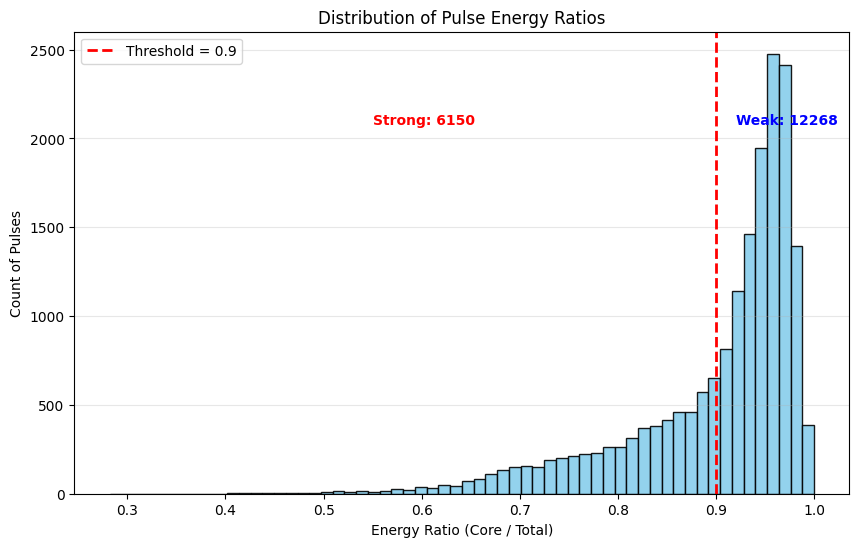


处理完成！总样本数: 18418
1. 弱混响 (Ratio >= 0.9): 12268
2. 强混响 (Ratio < 0.9): 6150
结果已记录至: D:\Project_Github\Indo-Pacific-humpback-dolphin\05_DistinguishbyEnergy\reverberation_metadata.csv


In [4]:
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

# ================= 1. 设置路径 =================
base_path = r"D:\Project_Github\Indo-Pacific-humpback-dolphin\00_Data\ClickTrains"
output_csv = r"D:\Project_Github\Indo-Pacific-humpback-dolphin\05_DistinguishbyEnergy\reverberation_metadata.csv"

# ================= 2. 核心计算函数 =================
def teager_energy_operator(signal):
    """计算一维信号的 Teager Energy Operator (TEO)"""
    signal = np.array(signal, dtype=float)
    teo = signal[1:-1]**2 - signal[:-2] * signal[2:]
    teo = np.insert(teo, 0, teo[0])
    teo = np.append(teo, teo[-1])
    teo[teo < 0] = 0
    return teo

def calculate_energy_ratio(file_path, window_us=25):
    """读取音频并计算核心脉冲能量占比"""
    y, sr = librosa.load(file_path, sr=None)
    teo = teager_energy_operator(y)
    peak_idx = np.argmax(teo)
    
    # 将微秒转换为采样点数
    num_samples_win = int(window_us * 1e-6 * sr)
    start_idx = max(0, peak_idx - num_samples_win)
    end_idx = min(len(teo), peak_idx + num_samples_win + 1)
    
    core_energy = np.sum(teo[start_idx:end_idx])
    total_energy = np.sum(teo)
    
    return (core_energy / total_energy) if total_energy > 0 else 0

# ================= 3. 批量处理 =================
if not os.path.exists(base_path):
    print(f"路径不存在: {base_path}")
else:
    results = []
    subfolders = [f.path for f in os.scandir(base_path) if f.is_dir()]

    print("开始分析音频文件...")
    for folder in tqdm(subfolders):
        wav_files = glob.glob(os.path.join(folder, "*.wav"))
        for file_path in wav_files:
            file_name = os.path.basename(file_path)
            if file_name.lower() == "pulsetrain.wav":
                continue
                
            try:
                ratio = calculate_energy_ratio(file_path)
                # 分类逻辑：大于等于0.9为弱混响，小于0.9为强混响
                label = "Weak_Reverberation" if ratio >= 0.9 else "Strong_Reverberation"
                
                results.append({
                    'folder': os.path.basename(folder),
                    'filename': file_name,
                    'ratio': ratio,
                    'label': label,
                    'original_path': os.path.abspath(file_path) # 保存绝对路径
                })
            except Exception as e:
                print(f"处理 {file_name} 出错: {e}")

    df = pd.DataFrame(results)

    # ================= 4. 绘制直方图 =================
    plt.figure(figsize=(10, 6))
    plt.hist(df['ratio'], bins=60, color='skyblue', edgecolor='black', alpha=0.9)
    plt.axvline(x=0.9, color='red', linestyle='--', linewidth=2, label='Threshold = 0.9')
    
    # 在图中添加文字说明分布情况
    weak_num = len(df[df['ratio'] >= 0.9])
    strong_num = len(df[df['ratio'] < 0.9])
    plt.text(0.92, plt.ylim()[1]*0.8, f'Weak: {weak_num}', color='blue', fontweight='bold')
    plt.text(0.55, plt.ylim()[1]*0.8, f'Strong: {strong_num}', color='red', fontweight='bold')

    plt.title('Distribution of Pulse Energy Ratios')
    plt.xlabel('Energy Ratio (Core / Total)')
    plt.ylabel('Count of Pulses')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # ================= 5. 保存 CSV 表格 =================
    # 使用 utf-8-sig 确保 Excel 打开中文路径不乱码
    df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    
    print("\n" + "="*50)
    print(f"处理完成！总样本数: {len(df)}")
    print(f"1. 弱混响 (Ratio >= 0.9): {weak_num}")
    print(f"2. 强混响 (Ratio < 0.9): {strong_num}")
    print(f"结果已记录至: {output_csv}")
    print("="*50)